# QKeras Divide and Conquer (DnC) Hardware Cost Modeling

This notebook provides a structured workflow for calculating **ASIC cell gate count** estimations for specific layer designs using actual physical synthesis points. It maps data plane attributes against an Arithmetic Cost Estimation (ACE) mathematical regression topology.

### Analytical Target Function:
$$\text{MAC Area} = a \cdot (X_{\text{bits}} \cdot W_{\text{bits}}) + b \cdot Z_{\text{bits}} + c$$
Where:
* $X_{\text{bits}}$: Input Bit-width
* $W_{\text{bits}}$: Weight Parameter Bit-width
* $Z_{\text{bits}}$: Accumulator register Bit-width
* $a, b, c$: Regression parameters reflecting actual hardware implementation metrics.

### Prerequisites
Ensure your Python environment contains the necessary data management and calculation toolsets:
```bash
# !pip install numpy pandas scipy matplotlib keras
```

In [2]:
import io
import numpy as np
import keras.ops.numpy as knp
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

## 1. Synthesis Sizing Data and Hardware Mappings

In [3]:
# Rule-of-thumb mapping between bits and gates in memory area estimate.
MemoryGatesPerBit = {
    "Register": 10.0,
    "SRAM": 1.0,
    "ROM": 0.1,
}

# Previously calculated 3D polynomial coefficients with relative MAE < 5%.
MAC_POLY3D_PARAMS = knp.array([7.70469119, 13.76199652, -92.15756665])

# Raw hardware target area measurements generated from synthesis runs
MAC24 = pd.read_csv(io.StringIO("\n283,280,286,313,325,336,356,,\n274,290,325,372,401,428,485,,\n285,325,388,510,568,614,713,,\n308,372,509,750,865,1002,1167,,\n336,427,617,1003,1151,1309,,,\n356,480,722,1165,,,,\n"), header=None)

MAC32 = pd.read_csv(io.StringIO("\n391,365,377,410,453,433,458,507,\n364,382,418,466,497,521,578,685,\n378,418,485,594,659,721,832,1035,\n408,466,596,843,1029,1151,1321,1642,\n432,521,724,1153,1363,1512,1797,,\n457,578,830,1330,1551,1782,2273,,\n"), header=None)

MAC40 = pd.read_csv(io.StringIO("\n458,457,470,500,522,527,551,605,664\n457,475,513,561,597,616,670,782,888\n470,513,579,699,766,816,928,1150,1358\n499,561,699,996,1161,1273,1499,1850,2189\n527,612,818,1275,1545,1691,2054,2516,\n549,670,927,1496,1798,2035,2490,3294,\n"), header=None)

MAC48 = pd.read_csv(io.StringIO("\n595,550,566,594,659,624,642,694,745\n551,566,607,654,727,707,763,881,984\n566,607,679,794,871,921,1017,1270,1489\n594,655,793,1097,1285,1401,1668,2101,2378\n624,711,921,1397,1816,1950,2277,2763,3301\n642,762,1015,1669,1974,2264,2718,3631,4415\n"), header=None)

## 2. Defining Cost Regression and Data Alignment Pipelines

In [5]:
def mac_gates_polynomial_3d(xyz, a, b, c):
    """Models hardware MAC area as a sum of multiplier, accumulator, and structural offsets."""
    x, y, z = xyz
    return a * x * y + b * z + c

def gen_mac_gate_model(do_plot=False):
    """Fits the polynomial coefficients based on raw data tables."""
    # Build dimension indexes matching raw matrices shapes
    abit = np.repeat(knp.array([24, 32, 40, 48]), 54)
    wbit = np.tile(np.repeat(knp.array([1, 2, 4, 8, 12, 16]), 9), 4)
    xbit = np.tile(knp.array([1, 2, 4, 8, 10, 12, 16, 24, 32]), 24)

    mac_arrs = []
    mac_arrs_index = {}
    valid_index = []
    start_pos = 0

    for mac_acc, acc_bits in zip([MAC24, MAC32, MAC40, MAC48], [24, 32, 40, 48]):
        cur_mac = mac_acc.to_numpy().reshape(-1)
        cur_valid_index = ~np.isnan(cur_mac)
        cur_valid_mac = cur_mac[cur_valid_index]
        
        end_pos = start_pos + len(cur_valid_mac)
        mac_arrs_index[acc_bits] = (start_pos, end_pos)
        mac_arrs += list(cur_valid_mac)
        start_pos = end_pos
        valid_index += list(cur_valid_index)

    # Strip invalid/NaN missing parameters mapping records
    xbit = xbit[valid_index]
    wbit = wbit[valid_index]
    abit = abit[valid_index]

    # Execute multidimensional optimization curve fitting
    params, covariance = curve_fit(mac_gates_polynomial_3d, (xbit, wbit, abit), mac_arrs)
    parameter_std_deviation = knp.sqrt(np.diag(covariance))

    mac_predict = mac_gates_polynomial_3d((xbit, wbit, abit), *params)
    mae_predict = knp.mean(knp.abs(mac_predict - mac_arrs)) / knp.mean(mac_arrs)

    if do_plot:
        # Render 3D tracking scattered plots
        fig = plt.figure(figsize=(10, 6))
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(xbit, wbit, mac_arrs, c=abit, cmap='magma', label='Synthesis Data')
        ax.set_xlabel('Input Bit-width (X)')
        ax.set_ylabel('Weight Bit-width (W)')
        ax.set_zlabel('Gate Count (Area)')
        plt.title('Raw Synthesis Sizing Vectors')
        plt.show()

        # Generate surface mesh plots for distinct configurations
        x_fit = np.linspace(min(xbit), max(xbit), 30)
        w_fit = np.linspace(min(wbit), max(wbit), 30)
        xmesh, wmesh = np.meshgrid(x_fit, w_fit)

        fig = plt.figure(figsize=(14, 10))
        for idx, acc_bits in enumerate([24, 32, 40, 48], 1):
            ax = fig.add_subplot(2, 2, idx, projection='3d')
            sp, ep = mac_arrs_index[acc_bits]
            
            ax.scatter(xbit[sp:ep], wbit[sp:ep], mac_arrs[sp:ep], color='red', label='Data')
            amesh = np.full((30, 30), acc_bits)
            poly_fit = mac_gates_polynomial_3d((xmesh, wmesh, amesh), *params)
            
            ax.plot_surface(xmesh, wmesh, poly_fit, cmap='viridis', alpha=0.6)
            ax.set_title(f'Accumulator Width: {acc_bits} Bits')
            ax.set_xlabel('X')
            ax.set_ylabel('W')
        plt.tight_layout()
        plt.show()

    return params, mae_predict, parameter_std_deviation

## 3. Cost Evaluation Functions

In [6]:
def get_ace_mac_gates(xbit, wbit, abit, regen_params=False):
    """Estimates localized macro gate deployment footprints."""
    if regen_params:
        mac_params, _, _ = gen_mac_gate_model(do_plot=True)
    else:
        mac_params = MAC_POLY3D_PARAMS

    return mac_gates_polynomial_3d((xbit, wbit, abit), *mac_params)

## 4. Run Optimization and Predict Sizing Costs

We now trigger the calibration optimizer to determine parameters $a, b, c$, evaluate fitness errors, and test arbitrary layer structural predictions.

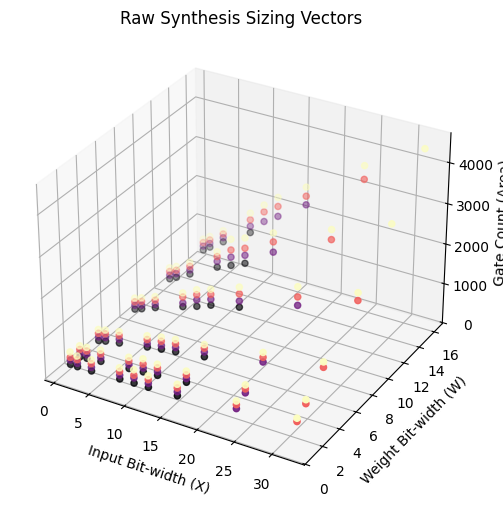

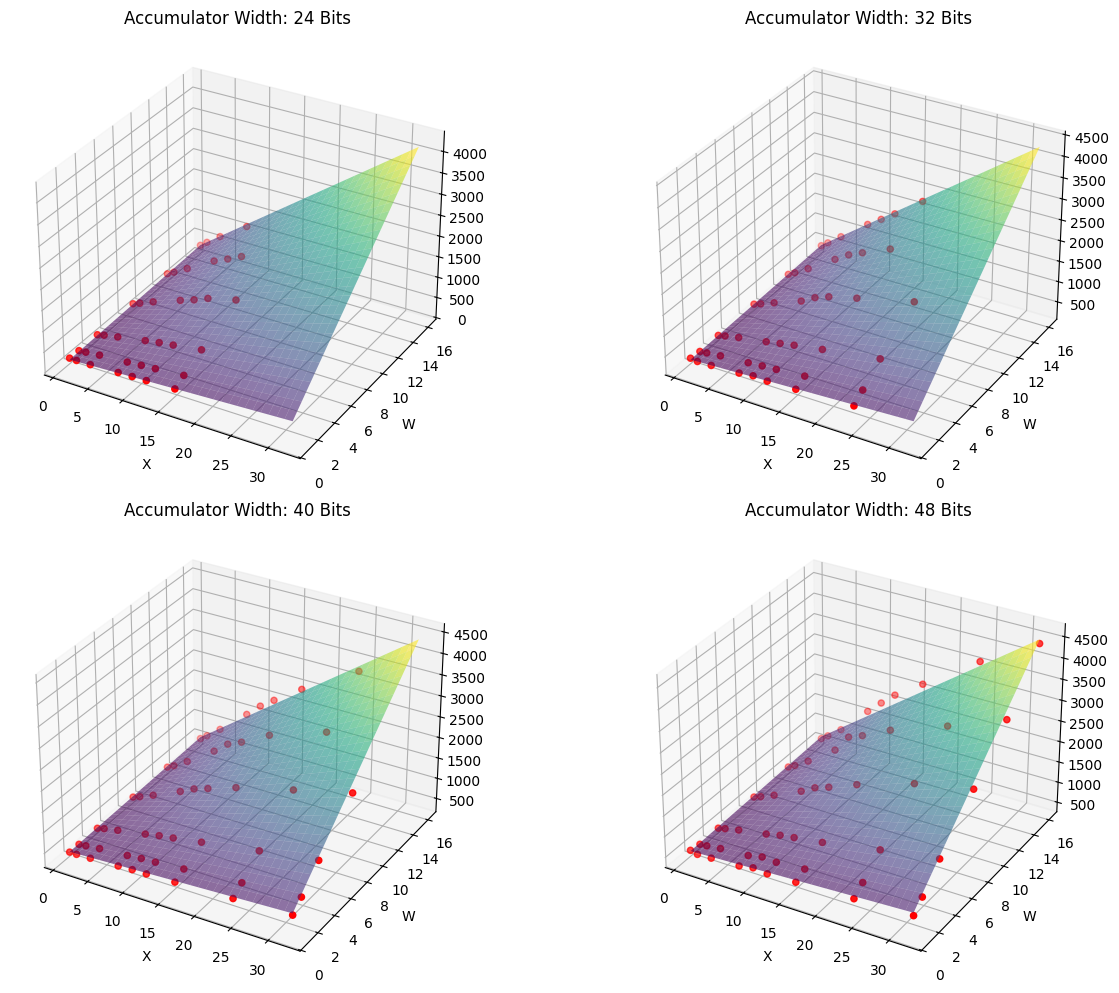

=== OPTIMIZATION RECOVERY LOG ===
Fitted Parameter 'a' (Mult Cost): 7.7047
Fitted Parameter 'b' (Accum Cost): 13.7620
Fitted Parameter 'c' (Base Offset): -92.1576
Model Mean Absolute Error (MAE):     4.64%

=== ARBITRARY HARDWARE PREDICTION TEST ===
Estimated total logic gates for (X=4, W=4, Acc=32): 471.50 Gates


In [7]:
# Run model calibration and generate visualization plots
fitted_params, mae, std_dev = gen_mac_gate_model(do_plot=True)

print("=== OPTIMIZATION RECOVERY LOG ===")
print(f"Fitted Parameter 'a' (Mult Cost): {fitted_params[0]:.4f}")
print(f"Fitted Parameter 'b' (Accum Cost): {fitted_params[1]:.4f}")
print(f"Fitted Parameter 'c' (Base Offset): {fitted_params[2]:.4f}")
print(f"Model Mean Absolute Error (MAE):     {mae*100:.2f}%")

print("\n=== ARBITRARY HARDWARE PREDICTION TEST ===")
# Estimate gate costs for a custom hardware configuration: 4-bit inputs, 4-bit weights, 32-bit accumulator
estimated_gates = get_ace_mac_gates(xbit=4, wbit=4, abit=32, regen_params=False)
print(f"Estimated total logic gates for (X=4, W=4, Acc=32): {estimated_gates:.2f} Gates")